# Practical No. 1: Air-Quality Data Cleaning Using R

**Name:** Sheshank Singh

**Roll No.:** 23102A0017

**Subject:** R Programming Laboratory

**Dataset:** Beijing Multi-Site Air Quality Dataset (UCI Repository)

**Station File Used:** PRSA_Data_Aotizhongxin_20130301-20170228.csv

## Aim
The objective of this practical is to develop as R program for cleaning a real-world air-quality dataset using loops, user-defined functions and error handling mechanisms. The program identifies missing and undefined values, differentiates between **NA**, **NULL**, and **NaN**, summarizes missing values, replaces missing numerical and categorical values, handles runtime errors using **tryCatch()**, and exports the cleaned dataset for further analysis.

## Dataset Description

The **Beijing Multi-Site Air Quality Dataset**, obtained from the **UCI Machine Learning Repository**, contains hourly observations collected from multiple air-quality monitoring stations in Beijing.

For this practical, only one monitoring station file is used:

> **PRSA_Data_Aotizhongxin_20130301-20170228.csv**

The dataset includes pollutant concentration, meteorological variables, and wind information collected over several years.

The important variables used in this practical are:

| Variable | Description |
|-----------|-------------|
| PM2.5 | Fine particulate matter concentration |
| PM10 | Coarse particulate matter concentration |
| SO2 | Sulphur dioxide concentration |
| NO2 | Nitrogen dioxide concentration |
| TEMP | Temperature |
| WSPM | Wind speed |
| wd | Wind direction |

Several observations contain missing values (**NA**) due to sensor failures, equipment maintenance, and communication issues, making the dataset suitable for demonstrating real-world data cleaning techniques.

## Required Library

This practical mainly uses Base R functions.

The **ggplot2** package will be used later for visualization.

In [1]:
# Install ggplot2 if required

if(!require(ggplot2)){
    install.packages("ggplot2")
    library(ggplot2)
}

Loading required package: ggplot2



## Task 1: Import and Inspect the Dataset

### Objective

The objective of this task is to import the selected air-quality dataset into R and perform an initial inspection of the data.

The program should:

- Import the CSV file.
- Display the first six records.
- Display the structure of the dataset.
- Display the dataset dimensions.
- Check whether missing values are present.
- Display the total number of missing values.
- Handle file-related errors using **tryCatch()**.

### Step 1: Setting up Dataset Path

In [4]:
file_path <- "PRSA_Data_Aotizhongxin_20130301-20170228.csv"
air_data <- tryCatch(
    {
        read.csv(file_path)
    },
    error = function(e){
        message("Error: Unable to load the dataset.")
        message("Reason: ", e$message)

        return(NULL)
    }
)

### Step 2: Verify Dataset Import

In [9]:
if(!is.null(air_data))
{
  cat("Dataset imported sucessfully.\n")
} else {
  cat("Dataset import failted.\n")
}

Dataset imported sucessfully.


### Step 3: Display the First Six Records

In [10]:
head(air_data)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,1,2013,3,1,0,4,4,4,7,300,77,-0.7,1023.0,-18.8,0,NNW,4.4,Aotizhongxin
2,2,2013,3,1,1,8,8,4,7,300,77,-1.1,1023.2,-18.2,0,N,4.7,Aotizhongxin
3,3,2013,3,1,2,7,7,5,10,300,73,-1.1,1023.5,-18.2,0,NNW,5.6,Aotizhongxin
4,4,2013,3,1,3,6,6,11,11,300,72,-1.4,1024.5,-19.4,0,NW,3.1,Aotizhongxin
5,5,2013,3,1,4,3,3,12,12,300,72,-2.0,1025.2,-19.5,0,N,2.0,Aotizhongxin
6,6,2013,3,1,5,5,5,18,18,400,66,-2.2,1025.6,-19.6,0,N,3.7,Aotizhongxin


### Step 4: Display the Dataset Structure

The **str()** function displays the internal structure of the dataset, including the data type of every variable.

In [11]:
str(air_data)

'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ PM2.5  : num  4 8 7 6 3 5 3 3 3 3 ...
 $ PM10   : num  4 8 7 6 3 5 3 6 6 8 ...
 $ SO2    : num  4 4 5 11 12 18 18 19 16 12 ...
 $ NO2    : num  7 7 10 11 12 18 32 41 43 28 ...
 $ CO     : int  300 300 300 300 300 400 500 500 500 400 ...
 $ O3     : num  77 77 73 72 72 66 50 43 45 59 ...
 $ TEMP   : num  -0.7 -1.1 -1.1 -1.4 -2 -2.2 -2.6 -1.6 0.1 1.2 ...
 $ PRES   : num  1023 1023 1024 1024 1025 ...
 $ DEWP   : num  -18.8 -18.2 -18.2 -19.4 -19.5 -19.6 -19.1 -19.1 -19.2 -19.3 ...
 $ RAIN   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ wd     : chr  "NNW" "N" "NNW" "NW" ...
 $ WSPM   : num  4.4 4.7 5.6 3.1 2 3.7 2.5 3.8 4.1 2.6 ...
 $ station: chr  "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" ...


## Step 5: Display Dataset Dimensions

The **nrow()** and **ncol()** functions return the total number of rows and columns present in the dataset.

In [12]:
cat("Number of Rows: ", nrow(air_data), "\n")
cat("Number of Columns: ", ncol(air_data))

Number of Rows:  35064 
Number of Columns:  18

### Step 6: Check Whether Missing Values Exist

The **anyNA()** function checks whether at least one missing value is present anywhere in the dataset.

In [17]:
if(anyNA(air_data)){
  cat("Missing values are present in the dataset")
} else {
  cat("No missing values found")
}

Missing values are present in the dataset

## Step 7: Count Total Missing Values

The **sum(is.na())** function calculates the total number of missing observations present in the dataset.

In [18]:
total_missing <- sum(is.na(air_data))
cat("Total Missing Values :", total_missing)

Total Missing Values : 7271

## Task 2: Understand NA, NULL and NaN

### Objective

R provides different representations for unavailable or undefined values.

This task demonstrates the difference between:

- **NA** (Missing observation)
- **NULL** (Empty object)
- **NaN** (Undefined numerical result)

The functions **is.na()**, **is.null()**, and **is.nan()** are used to identify these values.

In [19]:
x = c(10, 20, NA, 40)

y = NULL

z = c(5, 0/0, 7)

In [20]:
cat("NA Example:\n")
print(x)
print(is.na(x))

cat("\nNULL Example:\n")
print(y)
print(is.null(y))

cat("\nNaN Example:\n")
print(z)
print(is.nan(z))

NA Example:
[1] 10 20 NA 40
[1] FALSE FALSE  TRUE FALSE

NULL Example:
NULL
[1] TRUE

NaN Example:
[1]   5 NaN   7
[1] FALSE  TRUE FALSE


## Task 3: Create a Missing-Value Summary Function

### Objective

The objective of this task is to create a reusable user-defined function named **missing_summary()** that summarizes the missing values present in selected variables of the air-quality dataset.

The function should:

- Accept a data frame as input.
- Calculate the total number of records.
- Calculate the total number of missing values.
- Calculate the percentage of missing values.
- Generate a summary table.
- Display a warning if any selected variable contains more than **20% missing values**.

Using reusable functions reduces code duplication and improves the maintainability of data-cleaning programs.

### Selected Variables

The missing-value summary will be generated for the following variables:

- PM2.5
- PM10
- SO2
- NO2
- TEMP
- WSPM
- wd

## Step 1: Create a Vector of Selected Variables

Instead of writing repetitive code for every column, we first create a vector containing the names of all variables to be analysed.

This approach makes the program scalable because additional variables can easily be included by updating the vector.

In [21]:
selected_variables <- c(
  "PM2.5",
  "PM10",
  "SO2",
  "NO2",
  "TEMP",
  "WSPM",
  "wd"
)

### Step 2: Create the User-Defined Function

The **missing_summary()** function performs the following operations for each selected variable:

1. Checks whether the variable exists in the dataset.
2. Calculates the total number of observations.
3. Counts the missing values.
4. Computes the percentage of missing values.
5. Stores the results in a summary table.
6. Displays a warning if missing values exceed 20%.

The function uses a **for loop**, making it reusable for datasets containing multiple variables.

In [29]:
missing_summary <- function(data_frame)
{

  summary_table <- data.frame(
    Variable = character(),
    Total_Records = integer(),
    Missing_Values = integer(),
    Missing_Percentage = numeric(),
    stringsAsFactors = FALSE
  )

  for(variable in selected_variables)
  {
    if(variable %in% names(data_frame))
    {
      total_records <- nrow(data_frame)
      missing_values <- sum(is.na(data_frame[[variable]]))
      missing_percentage <- round(
        (missing_values / total_records) * 100, 2
      )
      summary_table <- rbind(
        summary_table,
        data.frame(
          Variable = variable,
          Total_Records = total_records,
          Missing_Values = missing_values,
          Missing_Percentage = missing_percentage
        )
      )

      if(missing_percentage > 20)
      {
        warning(
          paste(
            variable,
            "contains more than 20% missing values."
          )
        )
      }

    }
    else
    {
      warning(
        paste(
          "Variable",
          variable,
          "does not exist in the dataset."
        )
      )
    }
  }
  return(summary_table)
}

## Step 3: Generate the Missing-Value Summary

The generated summary table will contains:

- Variable Name
- Total Records
- Missing Values
- Missing Percentage

In [30]:
missing_summary_table = missing_summary(air_data)
missing_summary_table

Variable,Total_Records,Missing_Values,Missing_Percentage
<chr>,<int>,<int>,<dbl>
PM2.5,35064,925,2.64
PM10,35064,718,2.05
SO2,35064,935,2.67
NO2,35064,1023,2.92
TEMP,35064,20,0.06
WSPM,35064,14,0.04
wd,35064,81,0.23


## Task 4: Identify Invalid Numerical Results

### Objective

In data preprocessing, mathematical operations can generate invalid numerical values due to missing observations or division by zero.

In this task, a new variable named **pollution_ratio** is created using the following formula:

pollution_ratio = PM2.5/PM10

After creating the variable, the program identifies:

- Missing values (**NA**)
- Undefined numerical values (**NaN**)
- Positive infinity (**Inf**)
- Negative infinity (**-Inf**)

Finally, all **NaN**, **Inf**, and **-Inf** values are replaced with **NA** to prepare the dataset for further analysis.

### Step 1: Create a New Variable

The pollution ratio is calculated by dividing **PM2.5** concentration by **PM10** concentration.

In [34]:
air_data$pollution_ratio = air_data$PM2.5 / air_data$PM10

### Step 2: Display the First Few Values

In [35]:
head(air_data$pollution_ratio)

[1] 1 1 1 1 1 1

### Step 3: Count Missing Values (NA)

The **is.na()** function identifies missing observations in the newly created variable.

In [36]:
na_count = sum(is.na(air_data$pollution_ratio))
cat("Number of NA values :", na_count)

Number of NA values : 934

### Step 4: Count NaN Values

The **is.nan()** function identifies undefined numerical results such as **0/0**.

In [37]:
nan_count = sum(is.nan(air_data$pollution_ratio))
cat("Number of NaN values :", nan_count)

Number of NaN values : 0

### Step 5: Count Infinite Values

The **is.infinite()** function identifies both positive and negative infinity generated during mathematical operations.

In [38]:
infinite_count = sum(is.infinite(air_data$pollution_ratio))
cat("Number of Infinite Values :", infinite_count)

Number of Infinite Values : 0

In [39]:
cat("Summary Before Cleaning\n")
cat("-----------------------\n")

cat("NA Values       :", na_count, "\n")
cat("NaN Values      :", nan_count, "\n")
cat("Infinite Values :", infinite_count, "\n")

Summary Before Cleaning
-----------------------
NA Values       : 934 
NaN Values      : 0 
Infinite Values : 0 


### Step 6: Replace NaN and Infinite Values with NA

Undefined numerical values (**NaN**) and infinite values (**Inf** and **-Inf**) are converted into **NA**.

This allows all missing observations to be handled consistently in the later cleaning stages.

In [40]:
air_data$pollution_ratio[
  is.nan(air_data$pollution_ratio)
] <- NA

air_data$pollution_ratio[
  is.infinite(air_data$pollution_ratio)
] <- NA

### Step 7: Verify the Cleaning Process

After replacing invalid numerical values with **NA**, recount the values to ensure that no **NaN** or **Infinity** remains.

In [41]:
na_after <- sum(is.na(air_data$pollution_ratio))
nan_after <- sum(is.nan(air_data$pollution_ratio))
inf_after <- sum(is.infinite(air_data$pollution_ratio))

cat("Summary After Cleaning\n")
cat("----------------------\n")
cat("NA Values       :", na_after, "\n")
cat("NaN Values      :", nan_after, "\n")
cat("Infinite Values :", inf_after, "\n")

Summary After Cleaning
----------------------
NA Values       : 934 
NaN Values      : 0 
Infinite Values : 0 


## Task 5: Handle Missing Numerical Values Using a Loop

### Objective

The objective of this task is to replace missing values in selected numerical variables using the **median imputation** technique.

For each numerical variable, the program performs the following operations:

1. Check whether the variable exists in the dataset.
2. Count the number of missing values.
3. Calculate the median (ignoring missing values).
4. Replace missing values with the calculated median.
5. Display:
   - Variable name
   - Missing values before replacement
   - Median used
   - Missing values after replacement

### Selected Numerical Variables

The following numerical variables are cleaned using median imputation:

- PM2.5
- PM10
- SO2
- NO2
- TEMP
- WSPM

### Step 1: Creating Vector of Numerical Variables

In [42]:
numeric_variables <- c(
  "PM2.5",
  "PM10",
  "SO2",
  "NO2",
  "TEMP",
  "WSPM"
)

### Step 2: Store Missing Values Before Cleaning

In [43]:
missing_before <- c()

### Step 3: Perform Median Imputation Using a For Loop

The program iterates through every variable in the vector and performs the following operations:

- Verify that the variable exists.
- Count missing values.
- Calculate the median while ignoring missing values.
- Replace missing observations with the median.
- Display a summary of the cleaning process.

In [44]:
for(variable in numeric_variables)
{
 if(variable %in% names(air_data))
  {
    before_missing <- sum(is.na(air_data[[variable]]))
    missing_before[variable] <- before_missing
    median_value <- median(
      air_data[[variable]],
      na.rm = TRUE
    )
    air_data[[variable]][
      is.na(air_data[[variable]])
    ] <- median_value
    after_missing <- sum(is.na(air_data[[variable]]))
    cat("-----------------------------------------\n")
    cat("Variable :", variable, "\n")
    cat("Missing Values Before :", before_missing, "\n")
    cat("Median Used :", median_value, "\n")
    cat("Missing Values After :", after_missing, "\n\n")
  }
  else
  {
    cat("Variable", variable, "does not exist.\n\n")
  }
}

-----------------------------------------
Variable : PM2.5 
Missing Values Before : 925 
Median Used : 58 
Missing Values After : 0 

-----------------------------------------
Variable : PM10 
Missing Values Before : 718 
Median Used : 87 
Missing Values After : 0 

-----------------------------------------
Variable : SO2 
Missing Values Before : 935 
Median Used : 9 
Missing Values After : 0 

-----------------------------------------
Variable : NO2 
Missing Values Before : 1023 
Median Used : 53 
Missing Values After : 0 

-----------------------------------------
Variable : TEMP 
Missing Values Before : 20 
Median Used : 14.5 
Missing Values After : 0 

-----------------------------------------
Variable : WSPM 
Missing Values Before : 14 
Median Used : 1.4 
Missing Values After : 0 



## Task 6: Handle Missing Categorical Values

### Objective

To replace missing values in the **wd (Wind Direction)** variable using the **mode** of the variable.

Unlike numerical variables, categorical variables cannot be cleaned using the median or mean. Therefore, the most frequently occurring category (mode) is used to replace missing values.

In this task, we will:

1. Create a user-defined function named **calculate_mode()**.
2. Calculate the most frequently occurring wind direction.
3. Replace missing values in **wd** with the calculated mode.
4. Display the number of missing values before and after replacement.

## Why Use Mode for Categorical Variables?

Categorical variables contain labels instead of numerical values.

Examples of wind direction include:

- N
- NE
- E
- SE
- S
- SW
- W
- NW

### Step 1: Create the User-Defined Function

The **calculate_mode()** function determines the most frequently occurring category in a categorical variable.

The function perform operations like:

- Removes missing values.
- Counts the frequency of each category.
- Returns the category with the highest frequency.

In [48]:
calculate_mode <- function(variable)
{
  # Remove missing values
  variable <- variable[!is.na(variable)]

  # Count frequency of each category
  frequency_table <- table(variable)

  # Return the category with maximum frequency
  mode_value <- names(which.max(frequency_table))

  return(mode_value)
}

### Step 2: Count Missing Values Before Replacement

In [49]:
wd_missing_before <- sum(is.na(air_data$wd))
cat("Missing Values Before Replacement :", wd_missing_before)

Missing Values Before Replacement : 81

### Step 3: Calculate the Mode

In [50]:
wd_mode = calculate_mode(air_data$wd)
cat("Most Frequent Wind Direction (Mode) :", wd_mode)

Most Frequent Wind Direction (Mode) : NE

### Step 4: Replace Missing Values with the Mode

In [51]:
air_data$wd[
  is.na(air_data$wd)
] <- wd_mode

### Step 5: Verify the Cleaning Process


In [52]:
wd_missing_after <- sum(is.na(air_data$wd))
cat("Missing Values After Replacement :", wd_missing_after)

Missing Values After Replacement : 0

## Task 7: Implement Error Handling

### Objective

The objective of this task is to develop a reusable function named **clean_variable()** that performs missing-value treatment for numerical variables while handling common runtime errors gracefully using **tryCatch()**.

The function should:

1. Accept the dataset and variable name as input.
2. Check whether the variable exists in the dataset.
3. Verify that the variable is numerical.
4. Check whether the variable contains only missing values.
5. Calculate the median.
6. Replace missing values using the median.
7. Return the cleaned variable.

### Step 1: Create the clean_variable() Function

The **clean_variable()** function performs validation checks before cleaning the selected variable.

The function automatically:

- validates the variable,
- calculates the median,
- replaces missing values,
- returns the cleaned variable,
- and displays informative messages if any error occurs.

In [54]:
clean_variable <- function(data_frame, variable_name)
{
  tryCatch(
    {
      # Check whether variable exists
      if(!(variable_name %in% names(data_frame)))
      {
        stop("Variable does not exist in the dataset.")
      }
      variable <- data_frame[[variable_name]]
      # Check whether variable is numeric
      if(!is.numeric(variable))
      {
        stop("Selected variable is not numerical.")
      }
      # Check whether all values are missing
      if(all(is.na(variable)))
      {
        stop("Variable contains only missing values.")
      }
      # Calculate median
      median_value <- median(variable, na.rm = TRUE)
      # Validate median
      if(is.na(median_value))
      {
        stop("Median could not be calculated.")
      }
      # Replace missing values
      variable[is.na(variable)] <- median_value
      cat("--------------------------------------\n")
      cat("Variable :", variable_name, "\n")
      cat("Median Used :", median_value, "\n")
      cat("Cleaning Completed Successfully.\n\n")
      return(variable)
    },
    error = function(e)
    {
      message("ERROR: ", e$message)
      return(NULL)
    }
  )
}

### Step 2: Apply the Function to a Numerical Variable

The function is first tested on a valid numerical variable (**PM2.5**).

In [55]:
air_data$PM2.5 <- clean_variable(
  air_data,
  "PM2.5"
)

--------------------------------------
Variable : PM2.5 
Median Used : 58 
Cleaning Completed Successfully.



### Step 3: Test Error Handling for a Non-Existing Variable

The following example intentionally passes a variable name that is not present in the dataset.

In [57]:
clean_variable(
  air_data,
  "PM100"
)

ERROR: Variable does not exist in the dataset.



NULL

### Step 4: Test Error Handling for a Categorical Variable

The function is designed only for numerical variables.

Passing the **wd** variable should generate an appropriate error message.

In [58]:
clean_variable(
  air_data,
  "wd"
)

ERROR: Selected variable is not numerical.



NULL

### Step 5: Test Error Handling for a Variable Containing Only Missing Values

To demonstrate this condition, create a temporary variable containing only **NA** values and apply the cleaning function.

In [59]:
air_data$test_variable <- NA

clean_variable(
  air_data,
  "test_variable"
)

ERROR: Selected variable is not numerical.



NULL

## Task 8: Compare Missing Values Before and After Cleaning

### Objective

After completing the numerical and categorical missing-value treatment, it is important to compare the dataset before and after the cleaning process.

The comparison table helps evaluate the effectiveness of the preprocessing techniques by showing:

- Missing values before cleaning
- Missing values after cleaning

In [60]:
comparison_table <- data.frame(

  Variable = c(
    numeric_variables,
    "wd"
  ),

  Missing_Before = c(
    as.numeric(missing_before),
    wd_missing_before
  ),

  Missing_After = c(
    as.numeric(missing_after),
    wd_missing_after
  )

)

comparison_table$Values_Replaced <-
comparison_table$Missing_Before -
comparison_table$Missing_After

comparison_table

Variable,Missing_Before,Missing_After,Values_Replaced
<chr>,<dbl>,<dbl>,<dbl>
PM2.5,925,0,925
PM10,718,0,718
SO2,935,0,935
NO2,1023,0,1023
TEMP,20,0,20
WSPM,14,0,14
wd,81,0,81


## Task 9: Generate One Visualization

### Objective

Visualization is an important step in data preprocessing because it helps compare the dataset before and after cleaning in an intuitive manner.

In this task, a grouped bar chart is created to compare the number of missing values in the selected variables:

- Before data cleaning
- After data cleaning

### Step 1: Prepare Data for Visualization

In [62]:
plot_data <- data.frame(

  Variable = rep(
    comparison_table$Variable,
    2
  ),

  Missing_Values = c(
    comparison_table$Missing_Before,
    comparison_table$Missing_After
  ),

  Status = c(

    rep(
      "Before Cleaning",
      nrow(comparison_table)
    ),

    rep(
      "After Cleaning",
      nrow(comparison_table)
    )
  )
)
head(plot_data)

,Variable,Missing_Values,Status
,<chr>,<dbl>,<chr>
1,PM2.5,925,Before Cleaning
2,PM10,718,Before Cleaning
3,SO2,935,Before Cleaning
4,NO2,1023,Before Cleaning
5,TEMP,20,Before Cleaning
6,WSPM,14,Before Cleaning


## Step 2: Generate the Grouped Bar Chart

The grouped bar chart compares missing values before and after cleaning.

The graph contains:

- Suitable title
- Variable names on the horizontal axis
- Number of missing values on the vertical axis
- Legend indicating before and after cleaning

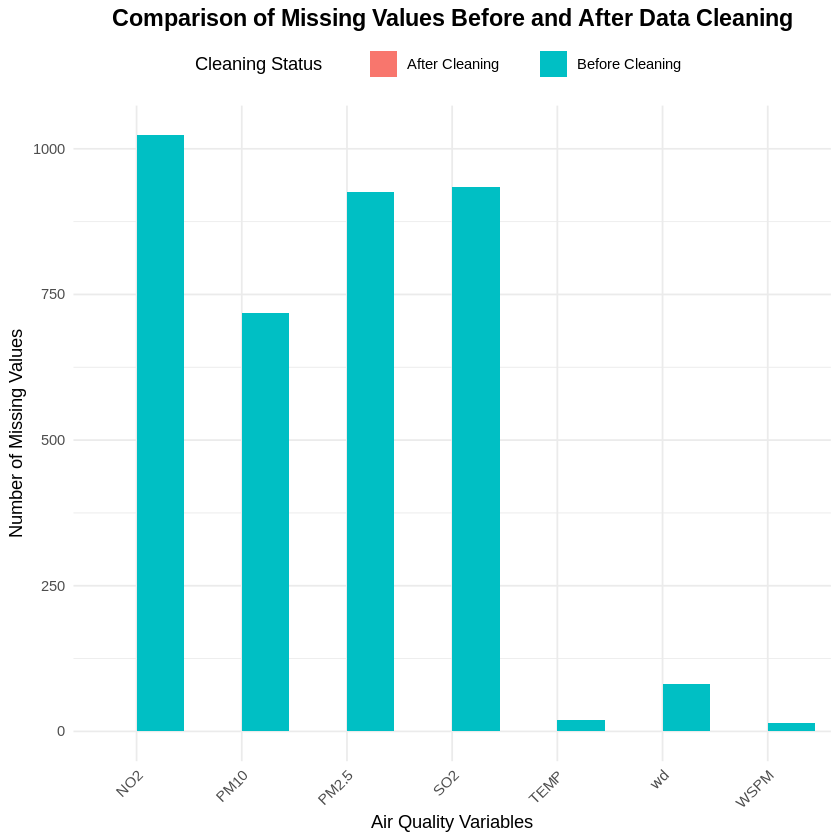

In [64]:
library(ggplot2)

ggplot(
  plot_data,
  aes(
    x = Variable,
    y = Missing_Values,
    fill = Status
  )
) +

geom_bar(
  stat = "identity",
  position = "dodge"
) +

labs(

  title = "Comparison of Missing Values Before and After Data Cleaning",

  x = "Air Quality Variables",

  y = "Number of Missing Values",

  fill = "Cleaning Status"

) +

theme_minimal() +

theme(

  plot.title = element_text(
    hjust = 0.5,
    face = "bold",
    size = 14
  ),

  axis.text.x = element_text(
    angle = 45,
    hjust = 1
  ),

  legend.position = "top"

)

### Step 3: Save the Visualization

In [65]:
ggsave(
  filename = "missing_values_comparison.png",
  width = 8,
  height = 5,
  dpi = 300
)

## Task 10: Export the Cleaned Dataset

### Objective

After completing all preprocessing operations, the cleaned dataset should be exported as a CSV file.

The exported file will be named: **cleaned_air_quality_data.csv**


In [66]:
write.csv(
  air_data,
  "cleaned_air_quality_data.csv",
  row.names = FALSE
)
cat("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.

## Practical Interpretation

The Beijing Multi-Site Air Quality dataset contained missing observations due to real-world issues such as sensor failures and communication interruptions. In this practical, missing values were successfully identified, summarized, and handled using appropriate preprocessing techniques. Numerical variables were cleaned using **median imputation**, while the categorical **wd** variable was cleaned using **mode imputation**. A reusable **missing_summary()** function and **clean_variable()** function were developed to improve code reusability. Error handling using **tryCatch()** ensured that invalid inputs and unexpected situations were managed gracefully without terminating the program. A grouped bar chart visually compared missing values before and after cleaning, clearly demonstrating the effectiveness of the preprocessing process. Finally, the cleaned dataset was exported successfully, making it suitable for statistical analysis and machine learning applications.

## Conclusion

This practical demonstrated the complete workflow of handling missing values in a real-world air-quality dataset using R